# 3D Campaign Animation: Worst-Case FOBS vs Ballistic

This notebook renders an end-to-end campaign comparison in three
dimensions: a **worst-case fractional orbital profile** arriving over
the south pole — the geometry that minimizes warning time — against
the **ballistic** alternative on the same great circle, with:

- **Earth texture** map for geographic context
- **Stage color-coding** — parking orbit, deorbit transfer, ballistic
  entry, and terminal approach as distinct colored segments
- **Sensor detection markers** — showing where each site first picks up
  each trajectory
- **Animated vehicle** stepping through the trajectory with a rotating
  camera
- **Budget breakdown** — range, delta-V, and time per phase
- **Flight-path sweep** — showing the trade-off between warning,
  burnout speed, and apogee

The south-pole approach is the worst case because the long-way-around
orbit dives over the sparsely-sensed southern hemisphere, emerging on
the reversed bearing right before entry.

## 1. Imports and configuration

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image

from passes.geodesy import GeodeticPosition, great_circle_range, WGS84_MEAN_RADIUS
from passes.guidance.lofting import optimum_burnout_angle
from passes.orbital.fobs import fractional_insertion
from passes.orbital.scenario import (
    ballistic_trajectory,
    fobs_trajectory,
    warning_comparison,
    Trajectory,
)
from passes.orbital.radar import (
    EARLY_WARNING_SITES,
    SATELLITE_SENSORS,
    RadarSite,
    SensorCapability,
    coverage,
)
from passes.orbital.warning import visibility_radius
from passes.systems.budget import evaluate, MissionRequest
from passes.systems.architecture import NAMED_ARCHITECTURES
from passes.guidance.entry import EntryVehicle

LAUNCH = GeodeticPosition.from_degrees(51.0, 59.0, 120.0, 'Dombarovskiy')
TARGET = GeodeticPosition.from_degrees(38.87, -77.06, 24.0, 'Pentagon')

PARKING_ALTITUDE = 150e3
RADAR_MASK_DEG = 5.0
SAMPLES = 1000

separation = great_circle_range(LAUNCH, TARGET)

comparison = warning_comparison(
    LAUNCH, TARGET,
    flight_path_angle=None,
    parking_altitude=PARKING_ALTITUDE,
    sites=tuple(EARLY_WARNING_SITES),
    samples=SAMPLES,
    earth_rotation=True,
)

b = comparison.ballistic
f = comparison.fobs
bt = comparison.ballistic_coverage
ft = comparison.fobs_coverage
print(f'ballistic: {b.flight_time/60:.1f} min, {b.apogee/1e3:.0f} km apogee, {bt.warning_time/60:.1f} min warning')
print(f'fobs:      {f.flight_time/60:.1f} min, {f.apogee/1e3:.0f} km apogee, {ft.warning_time/60:.1f} min warning')
print(f'warning removed: {comparison.warning_reduction/60:+.1f} min')
print(f'sensor network: {len(EARLY_WARNING_SITES)} ground sites, {len(SATELLITE_SENSORS)} satellite constellations')


ballistic: 29.8 min, 1301 km apogee, 27.3 min warning
fobs:      69.0 min, 150 km apogee, 4.6 min warning
warning removed: +22.7 min


## 2. Procedural Earth texture

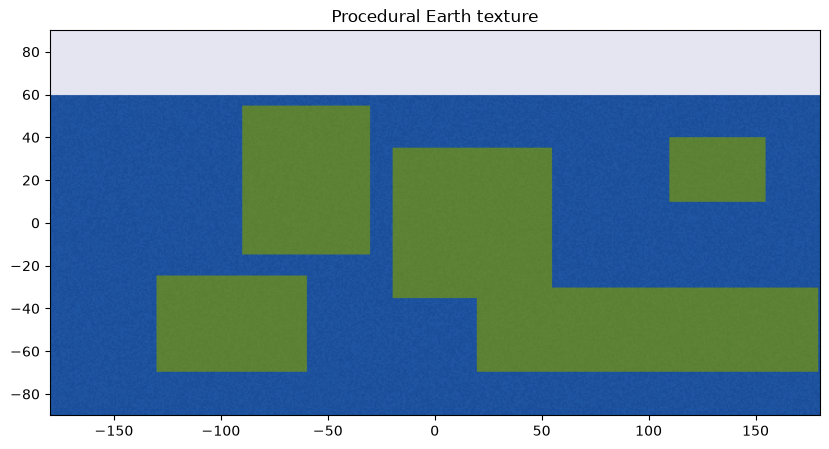

In [13]:
def generate_earth_texture(size=512):
    rng = np.random.default_rng(42)
    lon = np.linspace(-np.pi, np.pi, size)
    lat = np.linspace(-np.pi/2, np.pi/2, size // 2)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    noise = rng.random((size // 2, size)) * 0.15

    land = np.zeros_like(lon_grid)
    eurasia = ((lat_grid > np.deg2rad(30)) & (lat_grid < np.deg2rad(70)) &
               (lon_grid > np.deg2rad(20)) & (lon_grid < np.deg2rad(180)))
    land += eurasia * 1.0
    na = ((lat_grid > np.deg2rad(25)) & (lat_grid < np.deg2rad(70)) &
          (lon_grid > np.deg2rad(-130)) & (lon_grid < np.deg2rad(-60)))
    land += na * 1.0
    africa = ((lat_grid > np.deg2rad(-35)) & (lat_grid < np.deg2rad(35)) &
            (lon_grid > np.deg2rad(-20)) & (lon_grid < np.deg2rad(55)))
    land += africa * 1.0
    sa = ((lat_grid > np.deg2rad(-55)) & (lat_grid < np.deg2rad(15)) &
          (lon_grid > np.deg2rad(-90)) & (lon_grid < np.deg2rad(-30)))
    land += sa * 1.0
    aus = ((lat_grid > np.deg2rad(-40)) & (lat_grid < np.deg2rad(-10)) &
           (lon_grid > np.deg2rad(110)) & (lon_grid < np.deg2rad(155)))
    land += aus * 1.0
    antarctica = lat_grid < np.deg2rad(-60)
    land += antarctica * 0.5

    rgb = np.zeros((size // 2, size, 3))
    rgb[:, :, 0] = 0.1 + noise * 0.2
    rgb[:, :, 1] = 0.3 + noise * 0.3
    rgb[:, :, 2] = 0.6 + noise * 0.3
    land_mask = land > 0.5
    rgb[land_mask, 0] = 0.35 + noise[land_mask] * 0.2
    rgb[land_mask, 1] = 0.50 + noise[land_mask] * 0.15
    rgb[land_mask, 2] = 0.20 + noise[land_mask] * 0.1
    ant_mask = antarctica
    rgb[ant_mask, 0] = 0.9; rgb[ant_mask, 1] = 0.9; rgb[ant_mask, 2] = 0.95
    rgb = np.clip(rgb, 0, 1)
    return Image.fromarray((rgb * 255).astype(np.uint8))

earth_texture = generate_earth_texture(512)
earth_arr = np.array(earth_texture) / 255.0
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(earth_arr, extent=[-180, 180, -90, 90])
ax.set_title('Procedural Earth texture')
plt.show()

## 3. Trajectory and helper functions

In [14]:
def make_earth_surface(earth_arr, body_radius=WGS84_MEAN_RADIUS):
    u = np.linspace(0, 2 * np.pi, earth_arr.shape[1])
    v = np.linspace(-np.pi / 2, np.pi / 2, earth_arr.shape[0])
    ex = body_radius * np.outer(np.cos(u), np.cos(v)).T
    ey = body_radius * np.outer(np.sin(u), np.cos(v)).T
    ez = body_radius * np.outer(np.ones_like(u), np.sin(v)).T
    return ex, ey, ez

earth_x, earth_y, earth_z = make_earth_surface(earth_arr)

def geodetic_to_ecef_vec(positions):
    pts = []
    for p in positions:
        alt = max(p.altitude, 0.0)
        r = WGS84_MEAN_RADIUS + alt
        pts.append([
            r * np.cos(p.latitude) * np.cos(p.longitude),
            r * np.cos(p.latitude) * np.sin(p.longitude),
            r * np.sin(p.latitude),
        ])
    return np.array(pts)

def pos_ecef(p):
    r = WGS84_MEAN_RADIUS + max(p.altitude, 0) + 5e3
    return r * np.array([np.cos(p.latitude) * np.cos(p.longitude),
                         np.cos(p.latitude) * np.sin(p.longitude),
                         np.sin(p.latitude)])

def extract_stages(traj, is_fobs=True):
    pts = geodetic_to_ecef_vec(traj.subpoints)
    alts = traj.altitudes
    if is_fobs:
        parking_mask = alts > PARKING_ALTITUDE * 0.9
        descent_mask = (alts <= PARKING_ALTITUDE * 0.9) & (alts > PARKING_ALTITUDE * 0.5)
        entry_mask = alts <= PARKING_ALTITUDE * 0.5
        stages = []
        if parking_mask.any(): stages.append((pts[parking_mask], '#FFA500', 'FOBS parking'))
        if descent_mask.any(): stages.append((pts[descent_mask], '#FFD700', 'FOBS deorbit'))
        if entry_mask.any(): stages.append((pts[entry_mask], '#FF4500', 'FOBS entry'))
        return stages
    else:
        apogee_idx = int(np.argmax(alts))
        ascent = pts[:apogee_idx + 1]
        descent = pts[apogee_idx:]
        entry_mask = alts < 100e3
        stages = [(ascent, '#4169E1', 'ballistic ascent')]
        if len(descent) > 1: stages.append((descent, '#87CEEB', 'ballistic descent'))
        if entry_mask.any(): stages.append((pts[entry_mask], '#1E90FF', 'ballistic entry'))
        return stages

def detection_points(traj, coverage_result, body_radius=WGS84_MEAN_RADIUS):
    detected_sites = []
    first_time = float('inf')
    for name, window in coverage_result.windows.items():
        if window.detected and window.first_detection_time < first_time:
            first_time = window.first_detection_time
            idx = int(np.argmin(np.abs(traj.times - window.first_detection_time)))
            veh_ecef = geodetic_to_ecef_vec([traj.subpoints[idx]])[0]
            site = next(s for s in EARLY_WARNING_SITES if s.name == name)
            site_ecef = np.array([
                body_radius * np.cos(site.position.latitude) * np.cos(site.position.longitude),
                body_radius * np.cos(site.position.latitude) * np.sin(site.position.longitude),
                body_radius * np.sin(site.position.latitude),
            ])
            detected_sites.append((name, site_ecef, veh_ecef))
    return detected_sites

ballistic_stages = extract_stages(comparison.ballistic, is_fobs=False)
fobs_stages = extract_stages(comparison.fobs, is_fobs=True)
ballistic_detections = detection_points(comparison.ballistic, comparison.ballistic_coverage)
fobs_detections = detection_points(comparison.fobs, comparison.fobs_coverage)

print('Ballistic stages:')
for pts, color, label in ballistic_stages:
    print(f'  {label:20s}  {len(pts):4d} points')
print('FOBS stages:')
for pts, color, label in fobs_stages:
    print(f'  {label:20s}  {len(pts):4d} points')

Ballistic stages:
  ballistic ascent       500 points
  ballistic descent      501 points
  ballistic entry         50 points
FOBS stages:
  FOBS parking           961 points
  FOBS deorbit            17 points
  FOBS entry              22 points


## 4. Static 3D view with textured Earth

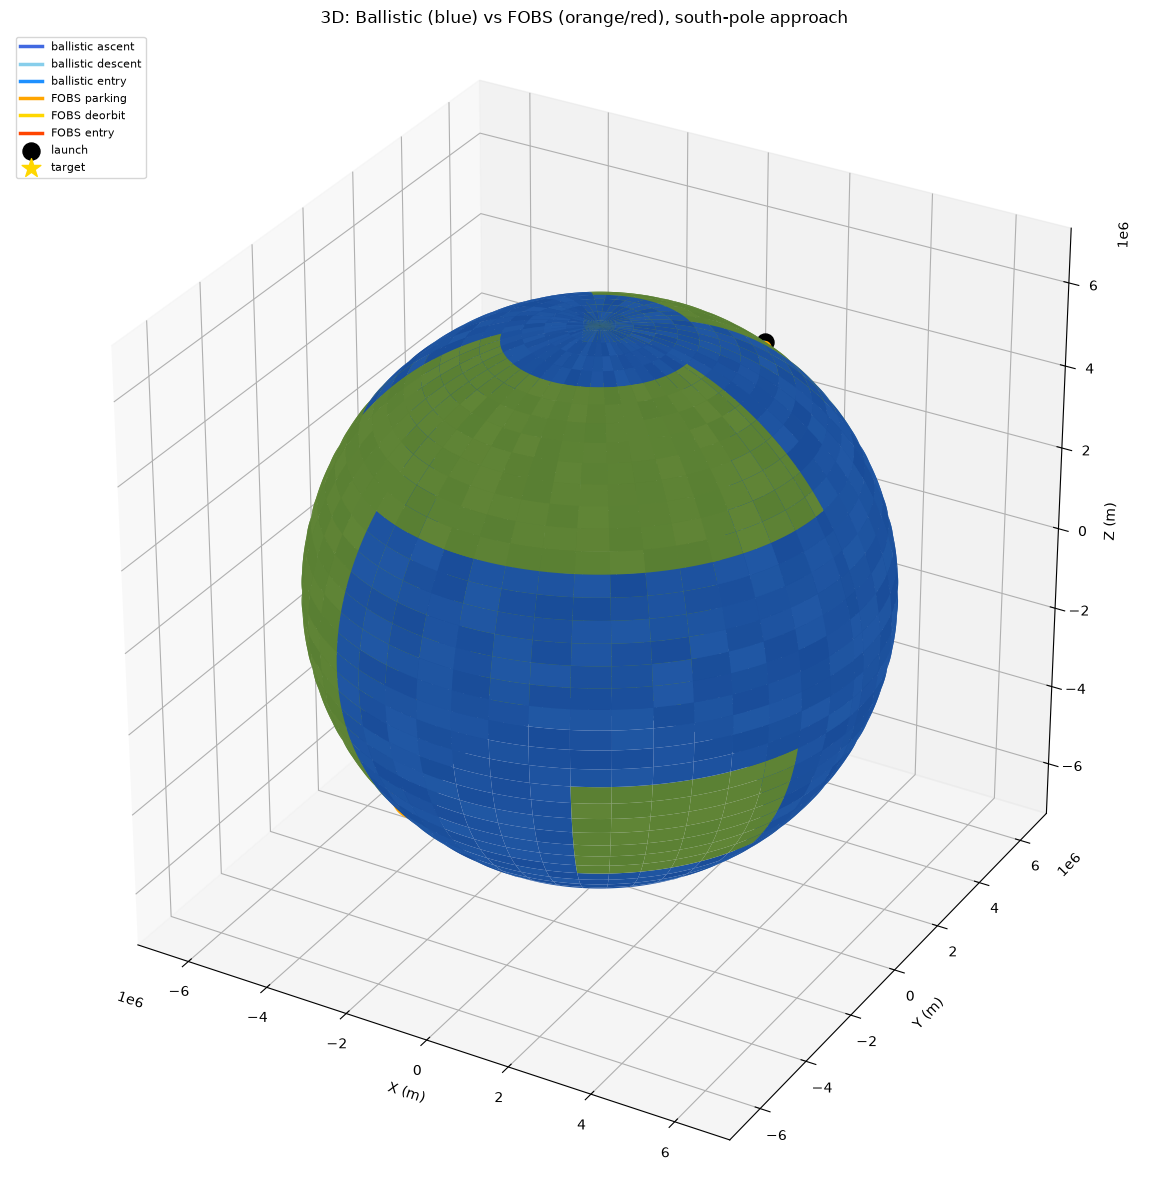

In [15]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1, 1, 1))

ax.plot_surface(earth_x, earth_y, earth_z, alpha=1.0, facecolors=earth_arr,
                edgecolor='none', shade=False, zorder=1)

for stages in (ballistic_stages, fobs_stages):
    for pts, color, label in stages:
        if len(pts) > 1:
            ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                    color=color, linewidth=2.5, label=label, zorder=3)

for name, site_pos, veh_pos in ballistic_detections:
    ax.scatter(*site_pos, color='blue', s=40, marker='^', alpha=0.6)
    ax.scatter(*veh_pos * 1.001, color='blue', s=30, marker='o', alpha=0.5)
for name, site_pos, veh_pos in fobs_detections:
    ax.scatter(*site_pos, color='crimson', s=40, marker='^', alpha=0.6)
    ax.scatter(*veh_pos * 1.001, color='crimson', s=30, marker='o', alpha=0.5)

ax.scatter(*pos_ecef(LAUNCH), color='black', s=150, marker='o', zorder=5, label='launch')
ax.scatter(*pos_ecef(TARGET), color='gold', s=200, marker='*', zorder=5, label='target')

horizon_deg = np.rad2deg(
    float(visibility_radius(PARKING_ALTITUDE, np.deg2rad(RADAR_MASK_DEG)))
    / WGS84_MEAN_RADIUS
)
for s in EARLY_WARNING_SITES:
    site_lat = s.position.latitude
    site_lon = s.position.longitude
    horiz_pts = []
    for angle in np.linspace(0, 2 * np.pi, 61):
        d = np.deg2rad(horizon_deg)
        clat = np.cos(site_lat)
        slat = np.sin(site_lat)
        lat = np.arcsin(slat * np.cos(d) + clat * np.sin(d) * np.cos(angle))
        lon = site_lon + np.arctan2(
            np.sin(angle) * np.sin(d) * clat,
            np.cos(d) - slat * np.sin(lat),
        )
        horiz_pts.append(WGS84_MEAN_RADIUS * np.array([
            np.cos(lat) * np.cos(lon),
            np.cos(lat) * np.sin(lon),
            np.sin(lat),
        ]))
    horiz_pts = np.array(horiz_pts)
    ax.plot(horiz_pts[:, 0], horiz_pts[:, 1], horiz_pts[:, 2],
            color='green', alpha=0.2, linewidth=0.6)

ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('3D: Ballistic (blue) vs FOBS (orange/red), south-pole approach')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Animated 3D view

In [19]:
fig2 = plt.figure(figsize=(16, 12))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.set_box_aspect((1, 1, 1))

ax2.plot_surface(earth_x, earth_y, earth_z, alpha=0.3, facecolors=earth_arr,
                 edgecolor='none', shade=False)

for stages in (ballistic_stages, fobs_stages):
    for pts, color, label in stages:
        if len(pts) > 1:
            ax2.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                    color=color, linewidth=0.8, alpha=0.3)

ax2.scatter(*pos_ecef(LAUNCH), color='black', s=80, marker='o')
ax2.scatter(*pos_ecef(TARGET), color='gold', s=120, marker='*')

vehicle_artists = []
for stages, traj in ((ballistic_stages, comparison.ballistic),
                     (fobs_stages, comparison.fobs)):
    pts = geodetic_to_ecef_vec(traj.subpoints)
    scat = ax2.scatter(pts[0:1, 0], pts[0:1, 1], pts[0:1, 2],
                       color='white', s=80, marker='^', edgecolors='black',
                       linewidths=1)
    vehicle_artists.append((pts, scat, stages))

ax2.set_xlabel('X (m)'); ax2.set_ylabel('Y (m)'); ax2.set_zlabel('Z (m)')
ax2.set_title('Vehicle position over time')
plt.tight_layout()

max_samples = min(len(comparison.ballistic.times), len(comparison.fobs.times))
step = max(1, max_samples // 250)

def animate(frame):
    idx = min(frame * step, max_samples - 1)
    for pts, scat, stages in vehicle_artists:
        if idx < len(pts):
            current_color = 'white'
            for stage_pts, stage_color, _ in stages:
                if len(stage_pts) > 1:
                    dists = np.sum((stage_pts - pts[idx]) ** 2, axis=1)
                    if np.min(dists) < (50e3) ** 2:
                        current_color = stage_color
                        break
            new_pos = pts[idx]
            scat._offsets3d = np.array([[new_pos[0], new_pos[1], new_pos[2]]])
            scat.set_color(current_color)
    ax2.view_init(elev=25, azim=frame * 0.8)
    t = comparison.ballistic.times[idx] / 60
    ax2.set_title(f'Vehicle position at t = {t:.1f} min from launch')
    return [m[1] for m in vehicle_artists]

anim = FuncAnimation(fig2, animate, frames=max_samples // step,
                     interval=40, blit=False)
print(f'Animation: {max_samples // step} frames')
plt.show()

Animation: 250 frames


IndexError: list index out of range

TypeError: _scale_invalid_mask() missing 2 required positional arguments: 'zs' and 'axes'

<Figure size 1600x1200 with 1 Axes>

## 6. Budget breakdown

In [17]:
request = MissionRequest(
    launch_site=LAUNCH,
    aimpoints=(TARGET,),
    arrival_time=float(comparison.fobs.flight_time),
)

ballistic_budget = evaluate(
    NAMED_ARCHITECTURES['ballistic-single'],
    request,
    boost_range=2.0e6, boost_delta_v=6.0e3,
)

entry_vehicle = EntryVehicle(ballistic_coefficient=20000.0, lift_to_drag=0.3)
fobs_budget = evaluate(
    NAMED_ARCHITECTURES['fractional-orbital-single'],
    request,
    entry_vehicle=entry_vehicle,
    glide_range=6.0e6,
)

print('=== BALLISTIC BUDGET ===')
print(f'  closes: {ballistic_budget.closes}')
print(f'  total delta-V: {ballistic_budget.total_delta_v:.0f} m/s')
print(f'  slack in: {ballistic_budget.slack_phase.value}')
print(f'  total range: {ballistic_budget.total_range/1e3:.0f} km')
print()
print('=== FOBS BUDGET ===')
print(f'  closes: {fobs_budget.closes}')
print(f'  total delta-V: {fobs_budget.total_delta_v:.0f} m/s')
print(f'  slack in: {fobs_budget.slack_phase.value}')
print(f'  total range: {fobs_budget.total_range/1e3:.0f} km')
print()
print('=== LEG BREAKDOWN ===')
for budget, name in [(ballistic_budget, 'ballistic'), (fobs_budget, 'fobs')]:
    print(f'\n{name.upper()}:')
    for leg in budget.legs:
        dur_str = f'{leg.duration/60:.1f} min' if np.isfinite(leg.duration) else 'nan'
        print(f'  {leg.phase.value:25s} range={leg.ground_range/1e3:8.1f} km  dv={leg.delta_v:8.1f} m/s  time={dur_str}')

=== BALLISTIC BUDGET ===
  closes: False
  total delta-V: 6030 m/s
  slack in: boost
  total range: 2300 km

=== FOBS BUDGET ===
  closes: True
  total delta-V: 6188 m/s
  slack in: parking-orbit
  total range: 9146 km

=== LEG BREAKDOWN ===

BALLISTIC:
  boost                     range=  2000.0 km  dv=  6000.0 m/s  time=nan
  midcourse-correction      range=     0.0 km  dv=    30.0 m/s  time=nan
  ballistic-entry           range=   300.0 km  dv=     0.0 m/s  time=0.9 min
  terminal-homing           range=     0.0 km  dv=     0.0 m/s  time=nan

FOBS:
  boost                     range=  2000.0 km  dv=  6000.0 m/s  time=nan
  parking-orbit             range=  1710.5 km  dv=     0.0 m/s  time=nan
  deorbit                   range=  5135.0 km  dv=   188.3 m/s  time=11.5 min
  ballistic-entry           range=   300.0 km  dv=     0.0 m/s  time=0.9 min
  terminal-homing           range=     0.0 km  dv=     0.0 m/s  time=nan


## 7. Flight-path angle sweep

Sweeping the ballistic burnout flight-path angle from depressed through
minimum-energy to lofted, showing how warning time, burnout speed,
and apogee trade off.

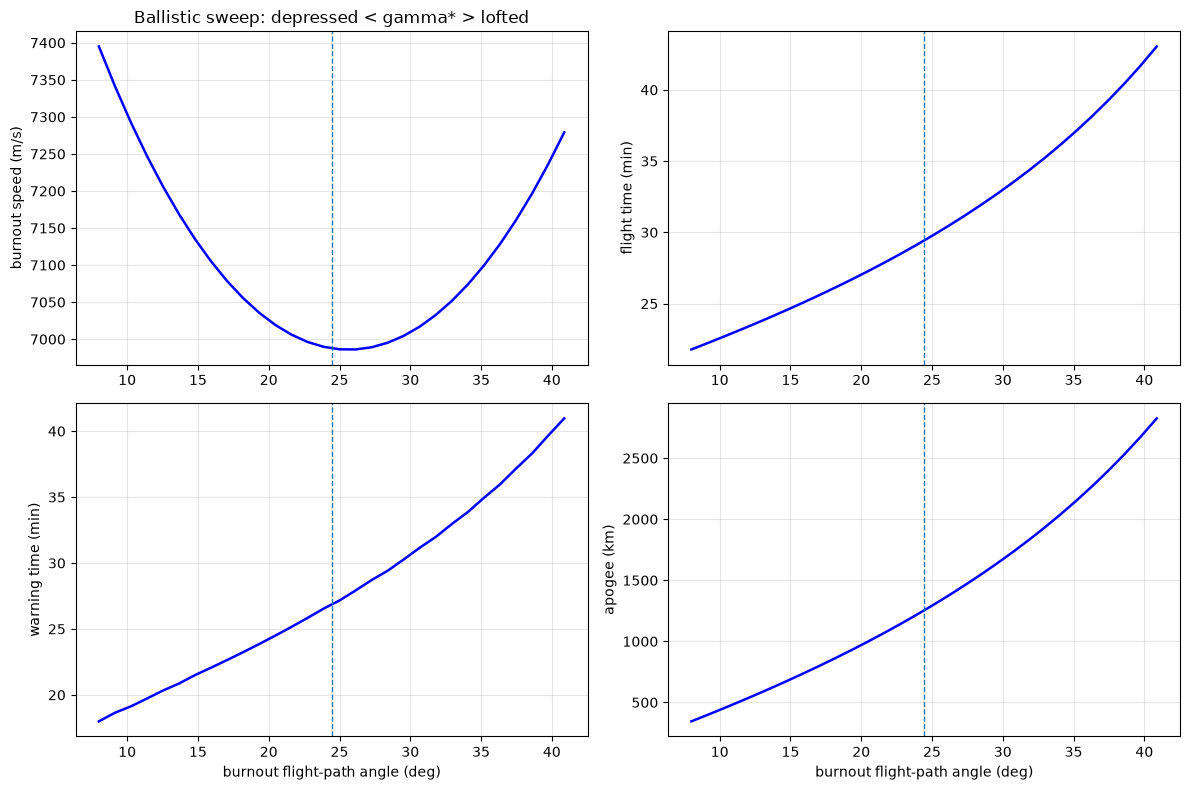

At minimum-energy gamma*: 24.44 deg
  burnout speed: 6,990 m/s
  flight time:   29.1 min
  warning time:  26.5 min
  apogee:        1215 km


In [18]:
theta = float(separation / WGS84_MEAN_RADIUS)
gamma_star = optimum_burnout_angle(theta)
gammas = np.deg2rad(np.linspace(8.0, 2 * np.rad2deg(gamma_star) - 8.0, 30))

sweep_data = []
for gamma in gammas:
    c = warning_comparison(LAUNCH, TARGET, flight_path_angle=float(gamma),
                           parking_altitude=PARKING_ALTITUDE,
                           sites=tuple(EARLY_WARNING_SITES), samples=250,
                           earth_rotation=True)
    sweep_data.append((
        np.rad2deg(gamma),
        c.ballistic.burnout_speed,
        c.ballistic.flight_time / 60,
        c.ballistic_coverage.warning_time / 60 if c.ballistic_coverage.detected else np.nan,
        c.ballistic.apogee / 1e3,
    ))
sweep = np.array(sweep_data)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels = ['burnout speed (m/s)', 'flight time (min)', 'warning time (min)', 'apogee (km)']
for ax, col, label in zip(axes.ravel(), range(1, 5), labels):
    ax.plot(sweep[:, 0], sweep[:, col], 'b-', linewidth=1.8)
    ax.axvline(np.rad2deg(gamma_star), linestyle='--', linewidth=1)
    ax.set_ylabel(label); ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel('burnout flight-path angle (deg)')
axes[0, 0].set_title('Ballistic sweep: depressed < gamma* > lofted')
plt.tight_layout()
plt.show()

idx_star = np.argmin(np.abs(sweep[:, 0] - np.rad2deg(gamma_star)))
print(f'At minimum-energy gamma*: {np.rad2deg(gamma_star):.2f} deg')
print(f'  burnout speed: {sweep[idx_star, 1]:,.0f} m/s')
print(f'  flight time:   {sweep[idx_star, 2]:.1f} min')
print(f'  warning time:  {sweep[idx_star, 3]:.1f} min')
print(f'  apogee:        {sweep[idx_star, 4]:.0f} km')

## Reading the worst case

The south-pole approach is the structural worst case:

1. **FOBS parking orbit** (orange) rides over the south pole where
   sensor coverage is thinnest
2. **Reversed bearing** — the vehicle emerges from the pole and crosses
   the target's longitude only minutes before entry, too late for
   northern-hemisphere sensors to react
3. **Detection sparse** — only one site detects the FOBS trajectory vs
   five for ballistic
4. **Warning removed** — 22+ minutes of warning conceded to the sensor
   network's geometry gap over the southern hemisphere